# Naive Forecasts

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import sys 

from pathlib import Path

project_root = Path.cwd().parent
sys.path.append(str(project_root))

from src.models.naive import *

In [2]:
inf_data = pd.read_csv('..//data//processed//combined_macro_data.csv', index_col = 'Date')
inf_data.index = pd.to_datetime(inf_data.index)
inf_data = inf_data.asfreq('MS')
inf_data.head()

,InflationRate,USD_PHP,UnemploymentRate,DubaiCrude,TargetRRP
Date,,,,,
1958-01-01,6.25000,2.0,NaN,NaN,NaN
1958-02-01,6.25000,2.0,NaN,NaN,NaN
1958-03-01,5.46875,2.0,NaN,NaN,NaN
1958-04-01,5.46875,2.0,NaN,NaN,NaN
1958-05-01,6.25000,2.0,NaN,NaN,NaN


In [3]:
n_splits = 5
months_forecast = 12
test_size = months_forecast
target_col = 'InflationRate'
inf_train = inf_data[:-test_size]
inf_test = inf_data[-test_size:]

## Train evaluation

In [4]:
naive_test(inf_train, n_splits = n_splits, test_size = test_size, target_col = target_col)

Folds: 5
Test Size: 12


,RMSE,MAE,R2
Fold,,,
1,1.311391,1.055347,-1.805766
2,0.988967,0.740575,-0.179733
3,1.492747,1.220889,-1.209910
4,1.479384,1.314080,-1.926316
5,1.632575,1.484359,-2.438819


In [5]:
seasonal_naive_test(inf_train, n_splits = n_splits, test_size = test_size, target_col = target_col)

Folds: 5
Test Size: 12


,RMSE,MAE,R2
Fold,,,
1,1.663316,1.524544,-3.513743
2,1.378721,1.189344,-1.292837
3,3.596012,3.193425,-11.824617
4,3.381186,3.002995,-14.286123
5,2.150826,1.868627,-4.968621


## II. Test results

In [6]:
n_test_forecast = naive_forecast(inf_train, target_col = target_col, months_ahead = months_forecast)
naive_test = pd.DataFrame(eval_metrics(inf_test['InflationRate'], n_test_forecast), index = ['Naive'])
naive_test.to_csv('..//outputs//tests//naive_test.csv')
naive_test

,RMSE,MAE,R2
Naive,2.864234,1.881748,-0.67007


In [7]:
sn_test_forecast = seasonal_naive_forecast(inf_train, target_col = target_col, months_ahead = months_forecast)
seasonal_naive_test = pd.DataFrame(eval_metrics(inf_test['InflationRate'], sn_test_forecast), index = ['Seasonal Naive'])
seasonal_naive_test.to_csv('..//outputs//tests//seasonal_naive_test.csv')
seasonal_naive_test

,RMSE,MAE,R2
Seasonal Naive,3.06522,2.332447,-0.912674


## III. Naive forecast

In [8]:
naive = naive_forecast(inf_data, target_col, months_forecast)
naive = pd.DataFrame(naive, columns = ['Naive'])
naive.to_csv('..//outputs//forecasts//naive_forecast.csv')

In [9]:
seasonal_naive = seasonal_naive_forecast(inf_data, target_col, months_forecast)
seasonal_naive = pd.DataFrame(seasonal_naive, columns = ['Seasonal Naive'])
seasonal_naive.to_csv('..//outputs//forecasts//seasonal_naive_forecast.csv')

## IV. Summary

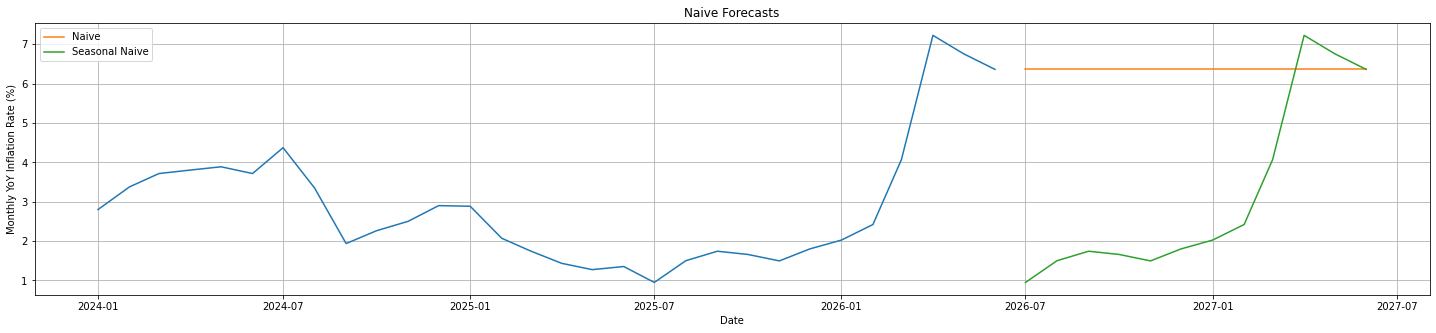

In [10]:
plt.figure(figsize = (25, 5))
plt.plot(inf_data[target_col]['2024':])
plt.title('Naive Forecasts')
plt.plot(naive, label = 'Naive')
plt.plot(seasonal_naive, label = 'Seasonal Naive')
plt.xlabel('Date')
plt.ylabel('Monthly YoY Inflation Rate (%)')
plt.legend()
plt.grid(True)
plt.savefig('..//outputs//figures//naive_forecast.jpg', dpi = 300, bbox_inches = 'tight')
plt.savefig('..//outputs//figures//naive_forecast.png', dpi = 300, bbox_inches = 'tight')
plt.show()